## Importing Packages and Reading the Data

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os 

In [2]:
nf=pd.read_csv('data/netflix_data.csv')

In [3]:
nf.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
infos=nf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
def all_in_info():
    unique=nf.nunique().to_frame(name='unique')
    nullsum=nf.isna().sum().to_frame(name='nullsum')
    dtypes=nf.dtypes.to_frame(name='dtypes')
    all_in=pd.concat([dtypes,unique,nullsum],axis=1)
    print(all_in)

In [6]:
nf.duplicated().sum()

np.int64(0)

### Coclusion

# cleaning Data

In [7]:
nf.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### Cleaning : country column 

In [8]:
# Cleaning the country the column 
nf['country'].isna().sum()

np.int64(831)

In [9]:
# WE need to replace the country column Nan values with the most occurring country name 
# check what is the most occurring name
nf['country'].mode()

0    United States
Name: country, dtype: object

In [10]:
#accessing the most occurrence 
nf['country'].mode()[0]

'United States'

In [11]:
#nf['country']=nf['country'].replace({np.nan:nf['country'].mode()[0]})
nf['country']=nf['country'].fillna(nf['country'].mode()[0])
nf['country']=nf['country'].astype(str)
nf['country'] = nf['country'].apply(lambda x : x.split(', ')[0])

In [12]:
nf['country'].isna().sum()

np.int64(0)

In [13]:
#nf['country'].nunique()
nf['country'].unique()

array(['United States', 'South Africa', 'India', 'United Kingdom',
       'Germany', 'Mexico', 'Turkey', 'Australia', 'Finland', 'China',
       'Nigeria', 'Japan', 'Spain', 'France', 'Belgium', 'South Korea',
       'Argentina', 'Russia', 'Canada', 'Hong Kong', 'Italy', '',
       'Ireland', 'New Zealand', 'Jordan', 'Colombia', 'Switzerland',
       'Israel', 'Brazil', 'Taiwan', 'Bulgaria', 'Poland', 'Saudi Arabia',
       'Thailand', 'Indonesia', 'Egypt', 'Kuwait', 'Malaysia', 'Vietnam',
       'Sweden', 'Lebanon', 'Romania', 'Philippines', 'Iceland',
       'Denmark', 'United Arab Emirates', 'Netherlands', 'Norway',
       'Syria', 'Mauritius', 'Austria', 'Czech Republic', 'Cameroon',
       'Uruguay', 'United Kingdom,', 'Kenya', 'Chile', 'Luxembourg',
       'Bangladesh', 'Portugal', 'Hungary', 'Senegal', 'Singapore',
       'Serbia', 'Namibia', 'Peru', 'Mozambique', 'Belarus', 'Ghana',
       'Zimbabwe', 'Puerto Rico', 'Pakistan', 'Cyprus', 'Paraguay',
       'Croatia', 'United St

In [14]:
nf['country'].value_counts()

country
United States     4041
India             1008
United Kingdom     626
Canada             271
Japan              259
                  ... 
Iran                 1
Slovenia             1
Guatemala            1
Jamaica              1
Somalia              1
Name: count, Length: 89, dtype: int64

### Cleaning: rating column

In [15]:
nf['rating'].isna().sum()

np.int64(4)

In [16]:
nf['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', '74 min', '84 min', '66 min', 'NR', nan,
       'TV-Y7-FV', 'UR'], dtype=object)

In [17]:
nf['rating']=nf['rating'].replace({'74 min':np.nan, '84 min':np.nan, '66 min':np.nan,'TV-Y7-FV':'TV-Y7'})

In [18]:
nf['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', nan, 'NR', 'UR'], dtype=object)

In [19]:
nf['rating'].isna().sum()

np.int64(7)

##### I tried to figure out what the best way to replace those nan values:
##### replace it with most occurrence or fill with 'UNRATED'
##### So nf['rating']=nf['rating'].fillna(nf['rating'].mode()[0])

In [20]:
nf['rating'].mode()

0    TV-MA
Name: rating, dtype: object

### Cleaning: director and cast columns

In [21]:
nf['director'].isna().sum()

np.int64(2634)

In [22]:
all_in_info()

              dtypes  unique  nullsum
show_id       object    8807        0
type          object       2        0
title         object    8807        0
director      object    4528     2634
cast          object    7692      825
country       object      89        0
date_added    object    1767       10
release_year   int64      74        0
rating        object      13        7
duration      object     220        3
listed_in     object     514        0
description   object    8775        0


In [23]:
nf['director'].value_counts()

director
Rajiv Chilaka              19
Raúl Campos, Jan Suter     18
Suhas Kadav                16
Marcus Raboy               16
Jay Karas                  14
                           ..
James Brown                 1
Ivona Juka                  1
Mu Chu                      1
Chandra Prakash Dwivedi     1
Majid Al Ansari             1
Name: count, Length: 4528, dtype: int64

In [24]:
'''FILLING THOSE HUGE SET OF NULL VALUES WITH ##'UNKNOWN'## '''
nf['director']=nf['director'].fillna('Unknown')

In [25]:
nf['director'].isna().sum()

np.int64(0)

In [26]:
nf['cast'].isna().sum()

np.int64(825)

In [27]:
'''FILLING THOSE HUGE SET OF NULL VALUES WITH ##'UNKNOWN'## '''
nf['cast']=nf['cast'].fillna('Unknown')

In [28]:
all_in_info()

              dtypes  unique  nullsum
show_id       object    8807        0
type          object       2        0
title         object    8807        0
director      object    4529        0
cast          object    7693        0
country       object      89        0
date_added    object    1767       10
release_year   int64      74        0
rating        object      13        7
duration      object     220        3
listed_in     object     514        0
description   object    8775        0


### Cleaning : date_added, rating, duration

In [29]:
nf['date_added'].isna().sum()

np.int64(10)

In [30]:
# There are multiple ways but i choose to replace with .mode 
mode_in=['date_added', 'rating', 'duration']
for i in mode_in:
    nf[i]=nf[i].fillna(nf[i].mode()[0])

In [31]:
all_in_info()

              dtypes  unique  nullsum
show_id       object    8807        0
type          object       2        0
title         object    8807        0
director      object    4529        0
cast          object    7693        0
country       object      89        0
date_added    object    1767        0
release_year   int64      74        0
rating        object      13        0
duration      object     220        0
listed_in     object     514        0
description   object    8775        0


In [32]:
nf['date_added']

0       September 25, 2021
1       September 24, 2021
2       September 24, 2021
3       September 24, 2021
4       September 24, 2021
               ...        
8802     November 20, 2019
8803          July 1, 2019
8804      November 1, 2019
8805      January 11, 2020
8806         March 2, 2019
Name: date_added, Length: 8807, dtype: object

In [33]:
nf['date_added']=nf['date_added'].apply(lambda x:x.lstrip(' '))

In [34]:
nf['month']=nf['date_added'].apply(lambda x: x.split(' ')[0])


In [35]:
nf['year']=nf['date_added'].apply(lambda x: x.split(',')[-1])
nf.rename(columns={'year':'uploaded_year'},inplace=True)

In [36]:
nf.drop(['show_id','date_added','description'],axis=1,inplace=True)

In [37]:
nf

,type,title,director,cast,country,release_year,rating,duration,listed_in,month,uploaded_year
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2020,PG-13,90 min,Documentaries,September,2021
1,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries",September,2021
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",September,2021
3,TV Show,Jailbirds New Orleans,Unknown,Unknown,United States,2021,TV-MA,1 Season,"Docuseries, Reality TV",September,2021
4,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",September,2021
...,...,...,...,...,...,...,...,...,...,...,...
8802,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2007,R,158 min,"Cult Movies, Dramas, Thrillers",November,2019
8803,TV Show,Zombie Dumb,Unknown,Unknown,United States,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies",July,2019
8804,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2009,R,88 min,"Comedies, Horror Movies",November,2019
8805,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2006,PG,88 min,"Children & Family Movies, Comedies",January,2020


In [38]:
all_in_info()

               dtypes  unique  nullsum
type           object       2        0
title          object    8807        0
director       object    4529        0
cast           object    7693        0
country        object      89        0
release_year    int64      74        0
rating         object      13        0
duration       object     220        0
listed_in      object     514        0
month          object      12        0
uploaded_year  object      14        0


## Visualization

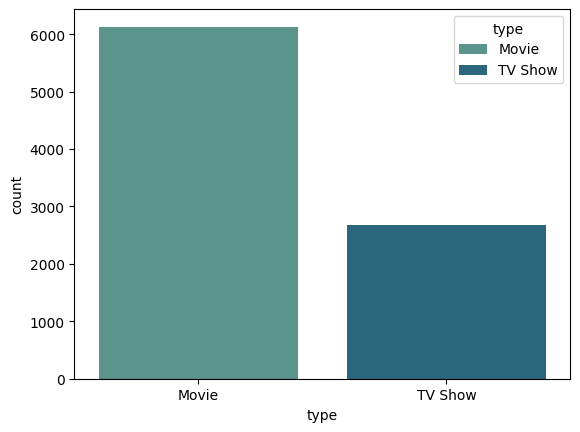

In [39]:
sns.countplot(x='type',hue='type',data=nf,palette='crest',legend=True)
plt.show()
#hue is used in sub division like movie got diffrent rating same with TV shows

## What is the month that have least releases?


In [40]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July',
               'August', 'September', 'October', 'November', 'December']


In [41]:
lr=nf.groupby('uploaded_year')['month'].value_counts().unstack()[month_order]

In [42]:
lr

month,January,February,March,April,May,June,July,August,September,October,November,December
uploaded_year,,,,,,,,,,,,
2008,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
2011,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,1.0,11.0,NaN,NaN
2012,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
2013,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0,2.0,3.0,2.0,2.0
2014,2.0,2.0,NaN,2.0,NaN,1.0,1.0,1.0,1.0,4.0,4.0,6.0
2015,1.0,4.0,5.0,5.0,6.0,6.0,7.0,2.0,7.0,14.0,4.0,21.0
2016,43.0,15.0,17.0,22.0,13.0,18.0,28.0,34.0,48.0,51.0,44.0,96.0


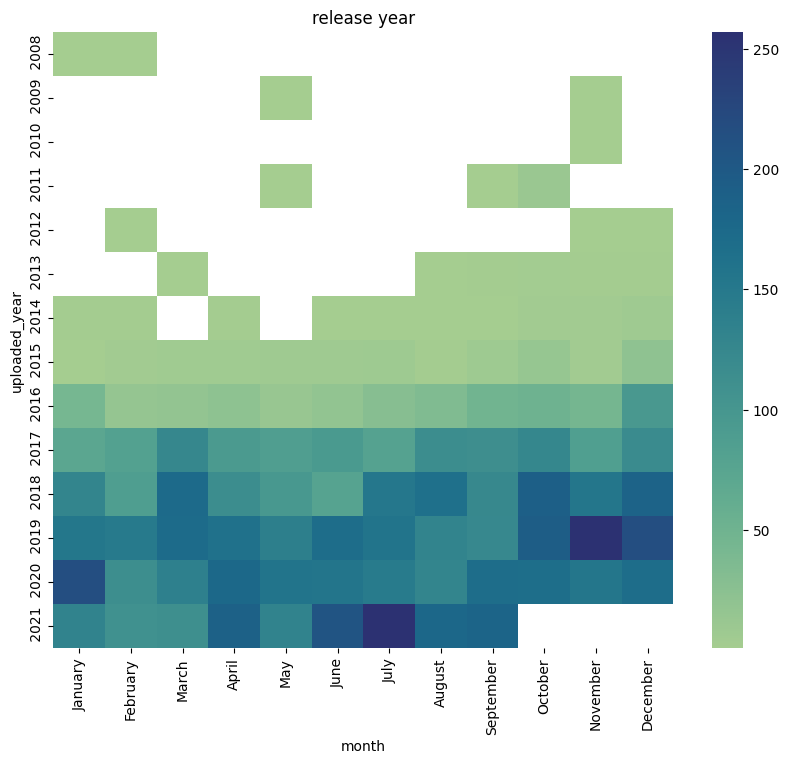

In [43]:
fig,ax=plt.subplots(1,1,figsize=(10,8))
ax=sns.heatmap(lr,cmap='crest')
plt.title('release year')
plt.show()

### what is the most genre in the data set movies / Tvshows ?

In [44]:
mv_filt=(nf['type']=='Movie')
mv_nf=nf[mv_filt]

In [45]:
mv_nf

,type,title,director,cast,country,release_year,rating,duration,listed_in,month,uploaded_year
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2020,PG-13,90 min,Documentaries,September,2021
6,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",United States,2021,PG,91 min,Children & Family Movies,September,2021
7,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...",United States,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",September,2021
9,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021,PG-13,104 min,"Comedies, Dramas",September,2021
12,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...",Germany,2021,TV-MA,127 min,"Dramas, International Movies",September,2021
...,...,...,...,...,...,...,...,...,...,...,...
8801,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...",United Arab Emirates,2015,TV-MA,96 min,"Dramas, International Movies, Thrillers",March,2016
8802,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2007,R,158 min,"Cult Movies, Dramas, Thrillers",November,2019
8804,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2009,R,88 min,"Comedies, Horror Movies",November,2019
8805,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2006,PG,88 min,"Children & Family Movies, Comedies",January,2020


In [46]:
genres={}
for genre in mv_nf['listed_in']:
    for i in genre.split(','):
        i=i.lstrip(' ')
        if i not in genres:
            genres[i]=1
        else:
            genres[i]+=1

g_mv_df=pd.DataFrame(list(genres.items()),columns=['genre','Number of movies'])

In [47]:
g_mv_df

,genre,Number of movies
0,Documentaries,869
1,Children & Family Movies,641
2,Dramas,2427
3,Independent Movies,756
4,International Movies,2752
5,Comedies,1674
6,Thrillers,577
7,Romantic Movies,616
8,Music & Musicals,375
9,Horror Movies,357


In [48]:
g_mv_df.sort_values(by='Number of movies',ascending=False).head()

,genre,Number of movies
4,International Movies,2752
2,Dramas,2427
5,Comedies,1674
0,Documentaries,869
11,Action & Adventure,859


In [49]:
g_mv_df['genre'].unique()

array(['Documentaries', 'Children & Family Movies', 'Dramas',
       'Independent Movies', 'International Movies', 'Comedies',
       'Thrillers', 'Romantic Movies', 'Music & Musicals',
       'Horror Movies', 'Sci-Fi & Fantasy', 'Action & Adventure',
       'Classic Movies', 'Anime Features', 'Sports Movies', 'Cult Movies',
       'Faith & Spirituality', 'LGBTQ Movies', 'Stand-Up Comedy',
       'Movies'], dtype=object)

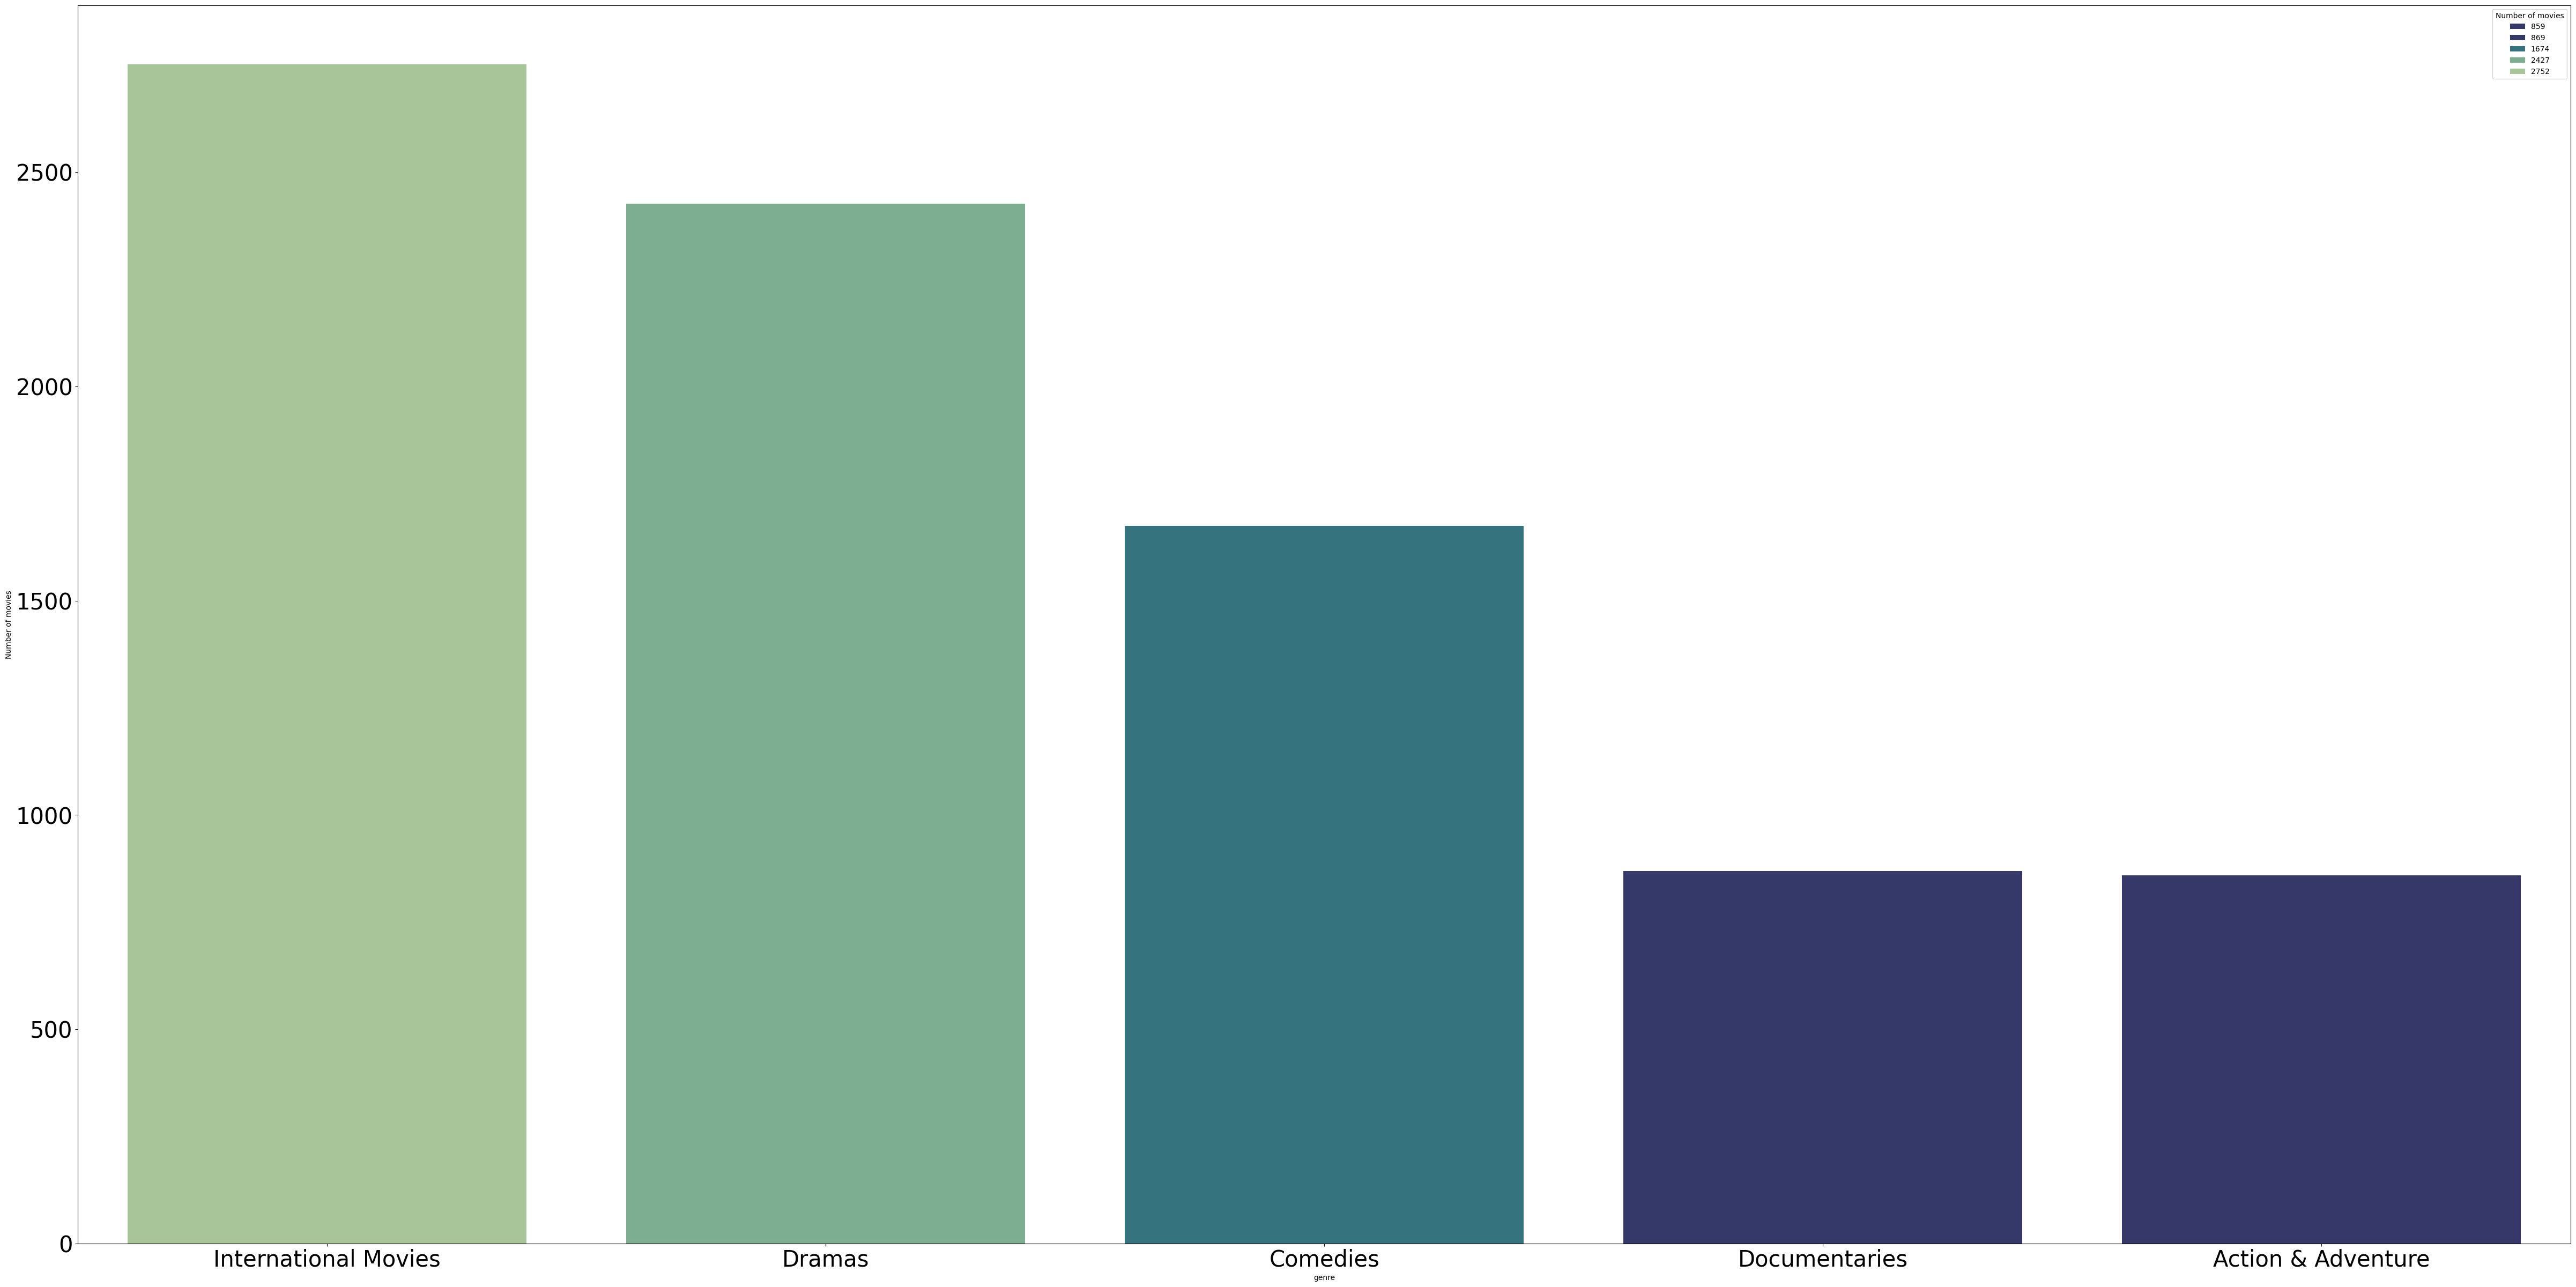

In [77]:
fig,ax=plt.subplots(figsize=(60,30))
ax=sns.barplot(x='genre',y='Number of movies', data=g_mv_df.sort_values(by='Number of movies',ascending=False).head(5),palette='crest_r',hue='Number of movies',
               legend=True)
plt.tick_params(labelsize=30)
plt.show()

In [86]:
g_mv_df.sort_values(by='Number of movies',ascending=False).reset_index().loc[0:5]

,index,genre,Number of movies
0,4,International Movies,2752
1,2,Dramas,2427
2,5,Comedies,1674
3,0,Documentaries,869
4,11,Action & Adventure,859
5,3,Independent Movies,756


In [51]:
# genres for TV shows

filt=(nf['type']=='TV Show')
tv_nf=nf[filt]
genres={}

for genre in tv_nf['listed_in']:
    for i in genre.split(','):
        i=i.strip(' ')
        if i not in genres:
            genres[i]=1
        else:
            genres[i]+=1




In [52]:
g_tv_df=pd.DataFrame(list(genres.items()),columns=['genre','No_of_tv_shows'])

In [53]:
g_tv_df

,genre,No_of_tv_shows
0,International TV Shows,1351
1,TV Dramas,763
2,TV Mysteries,98
3,Crime TV Shows,470
4,TV Action & Adventure,168
5,Docuseries,395
6,Reality TV,255
7,Romantic TV Shows,370
8,TV Comedies,581
9,TV Horror,75


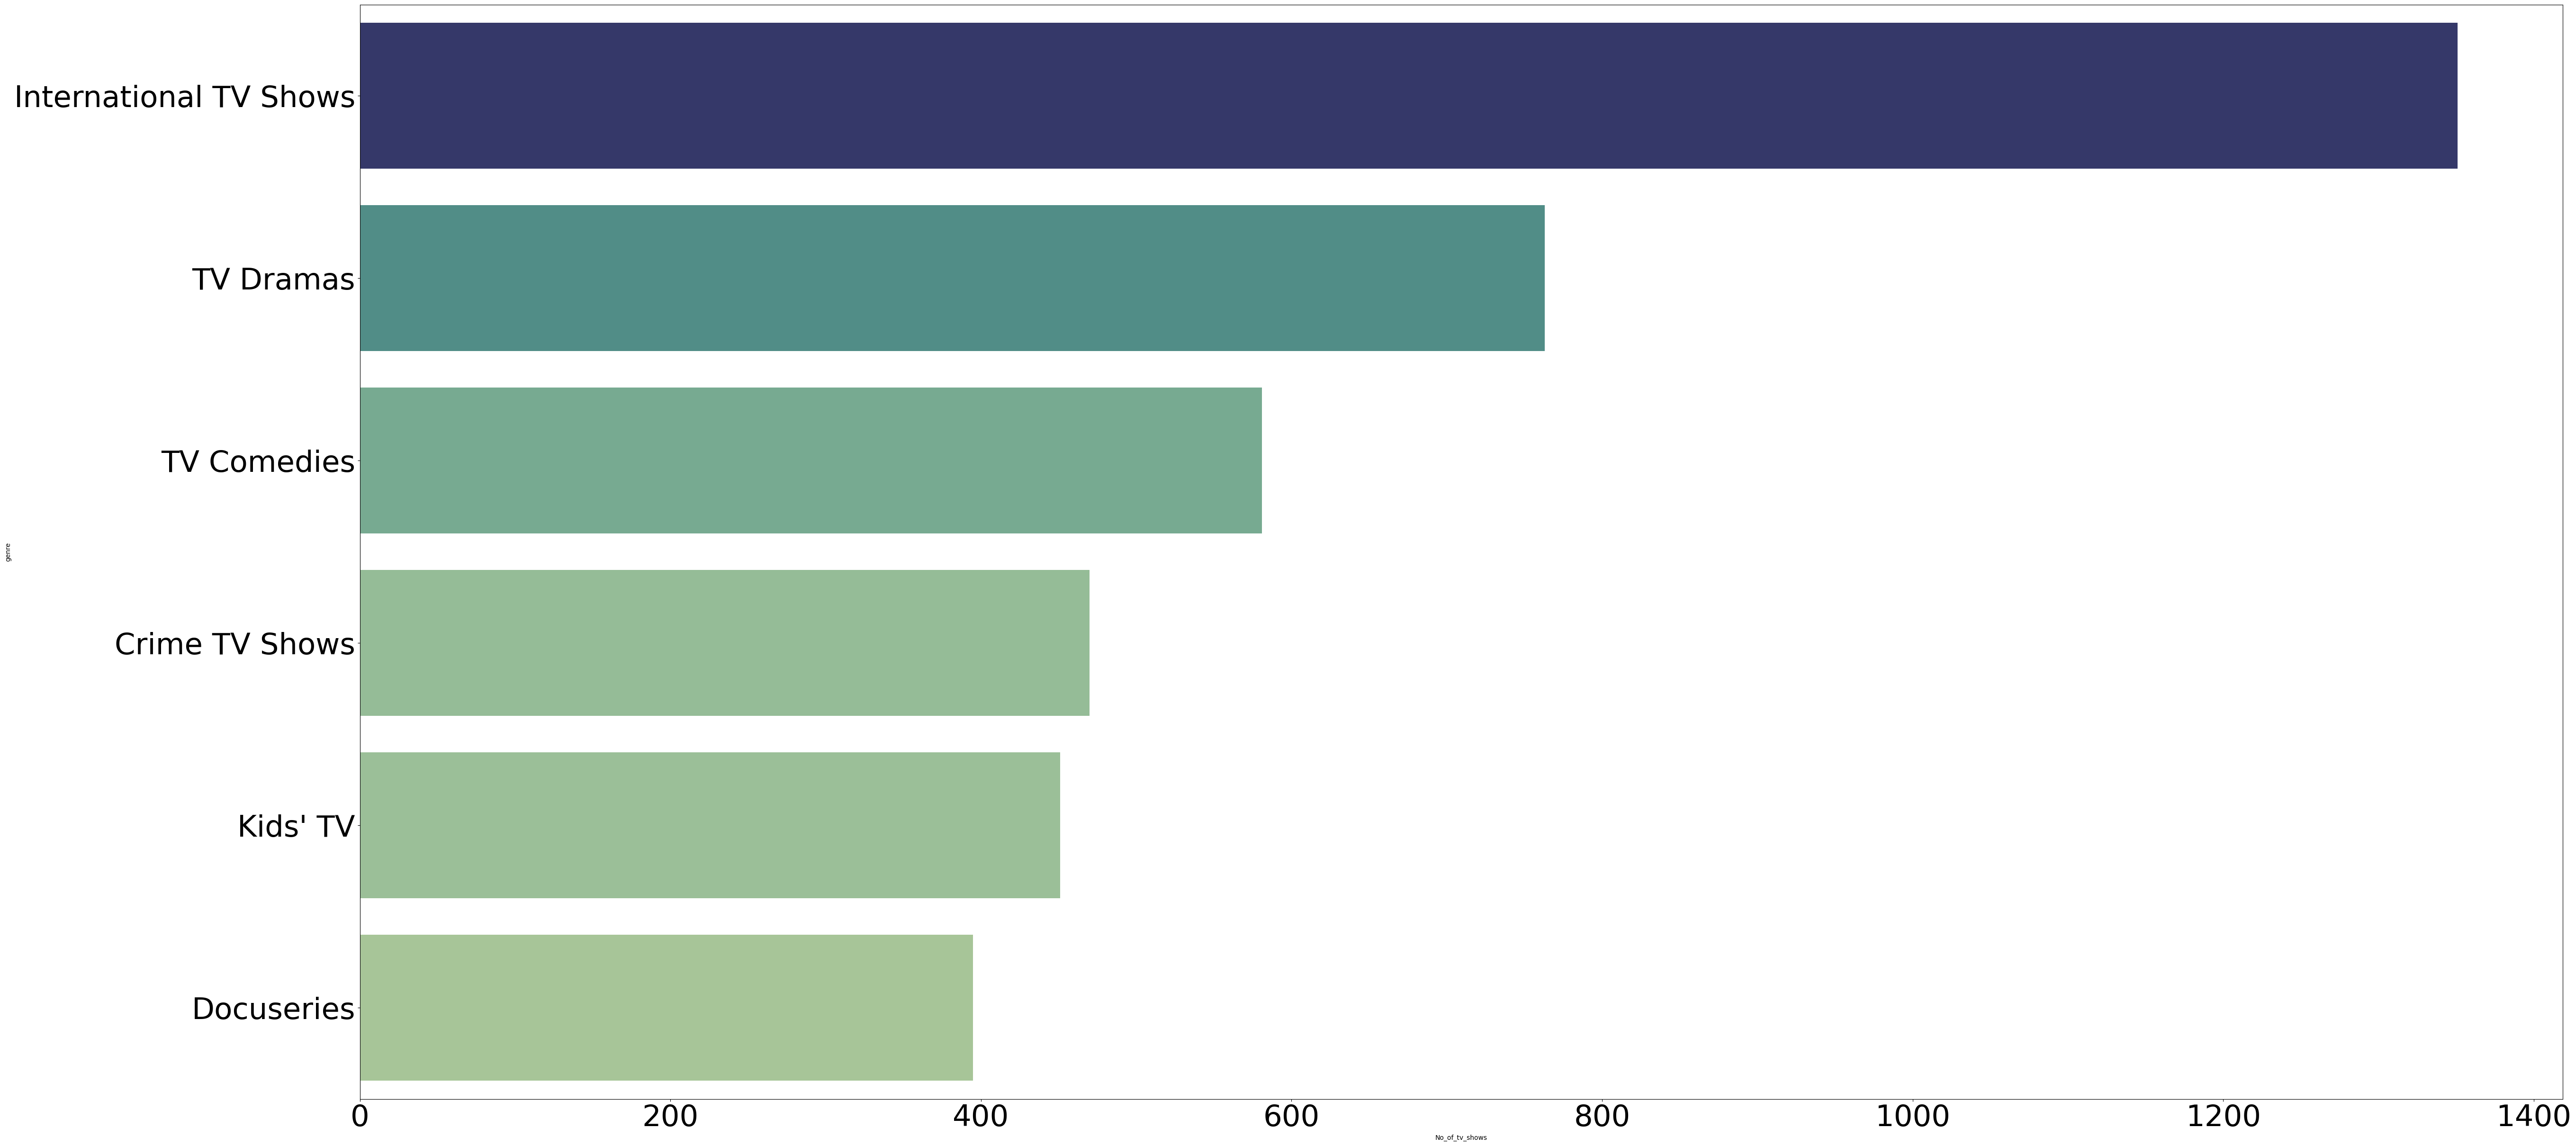

In [54]:
fig,ax=plt.subplots(figsize=(60,30))
ax=sns.barplot(y='genre',x='No_of_tv_shows',data=g_tv_df.sort_values(by='No_of_tv_shows',ascending=False).loc[0:5],hue='No_of_tv_shows',\
              palette='crest',legend=False)
plt.tick_params(labelsize=45)
plt.show()

In [55]:
nf

,type,title,director,cast,country,release_year,rating,duration,listed_in,month,uploaded_year
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2020,PG-13,90 min,Documentaries,September,2021
1,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries",September,2021
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",September,2021
3,TV Show,Jailbirds New Orleans,Unknown,Unknown,United States,2021,TV-MA,1 Season,"Docuseries, Reality TV",September,2021
4,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",September,2021
...,...,...,...,...,...,...,...,...,...,...,...
8802,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2007,R,158 min,"Cult Movies, Dramas, Thrillers",November,2019
8803,TV Show,Zombie Dumb,Unknown,Unknown,United States,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies",July,2019
8804,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2009,R,88 min,"Comedies, Horror Movies",November,2019
8805,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2006,PG,88 min,"Children & Family Movies, Comedies",January,2020


## In which year has been released largest number of movies/ Tvshows?

In [56]:
rl_gp=nf.groupby('release_year')['type'].value_counts().unstack(level=-1).fillna(0)

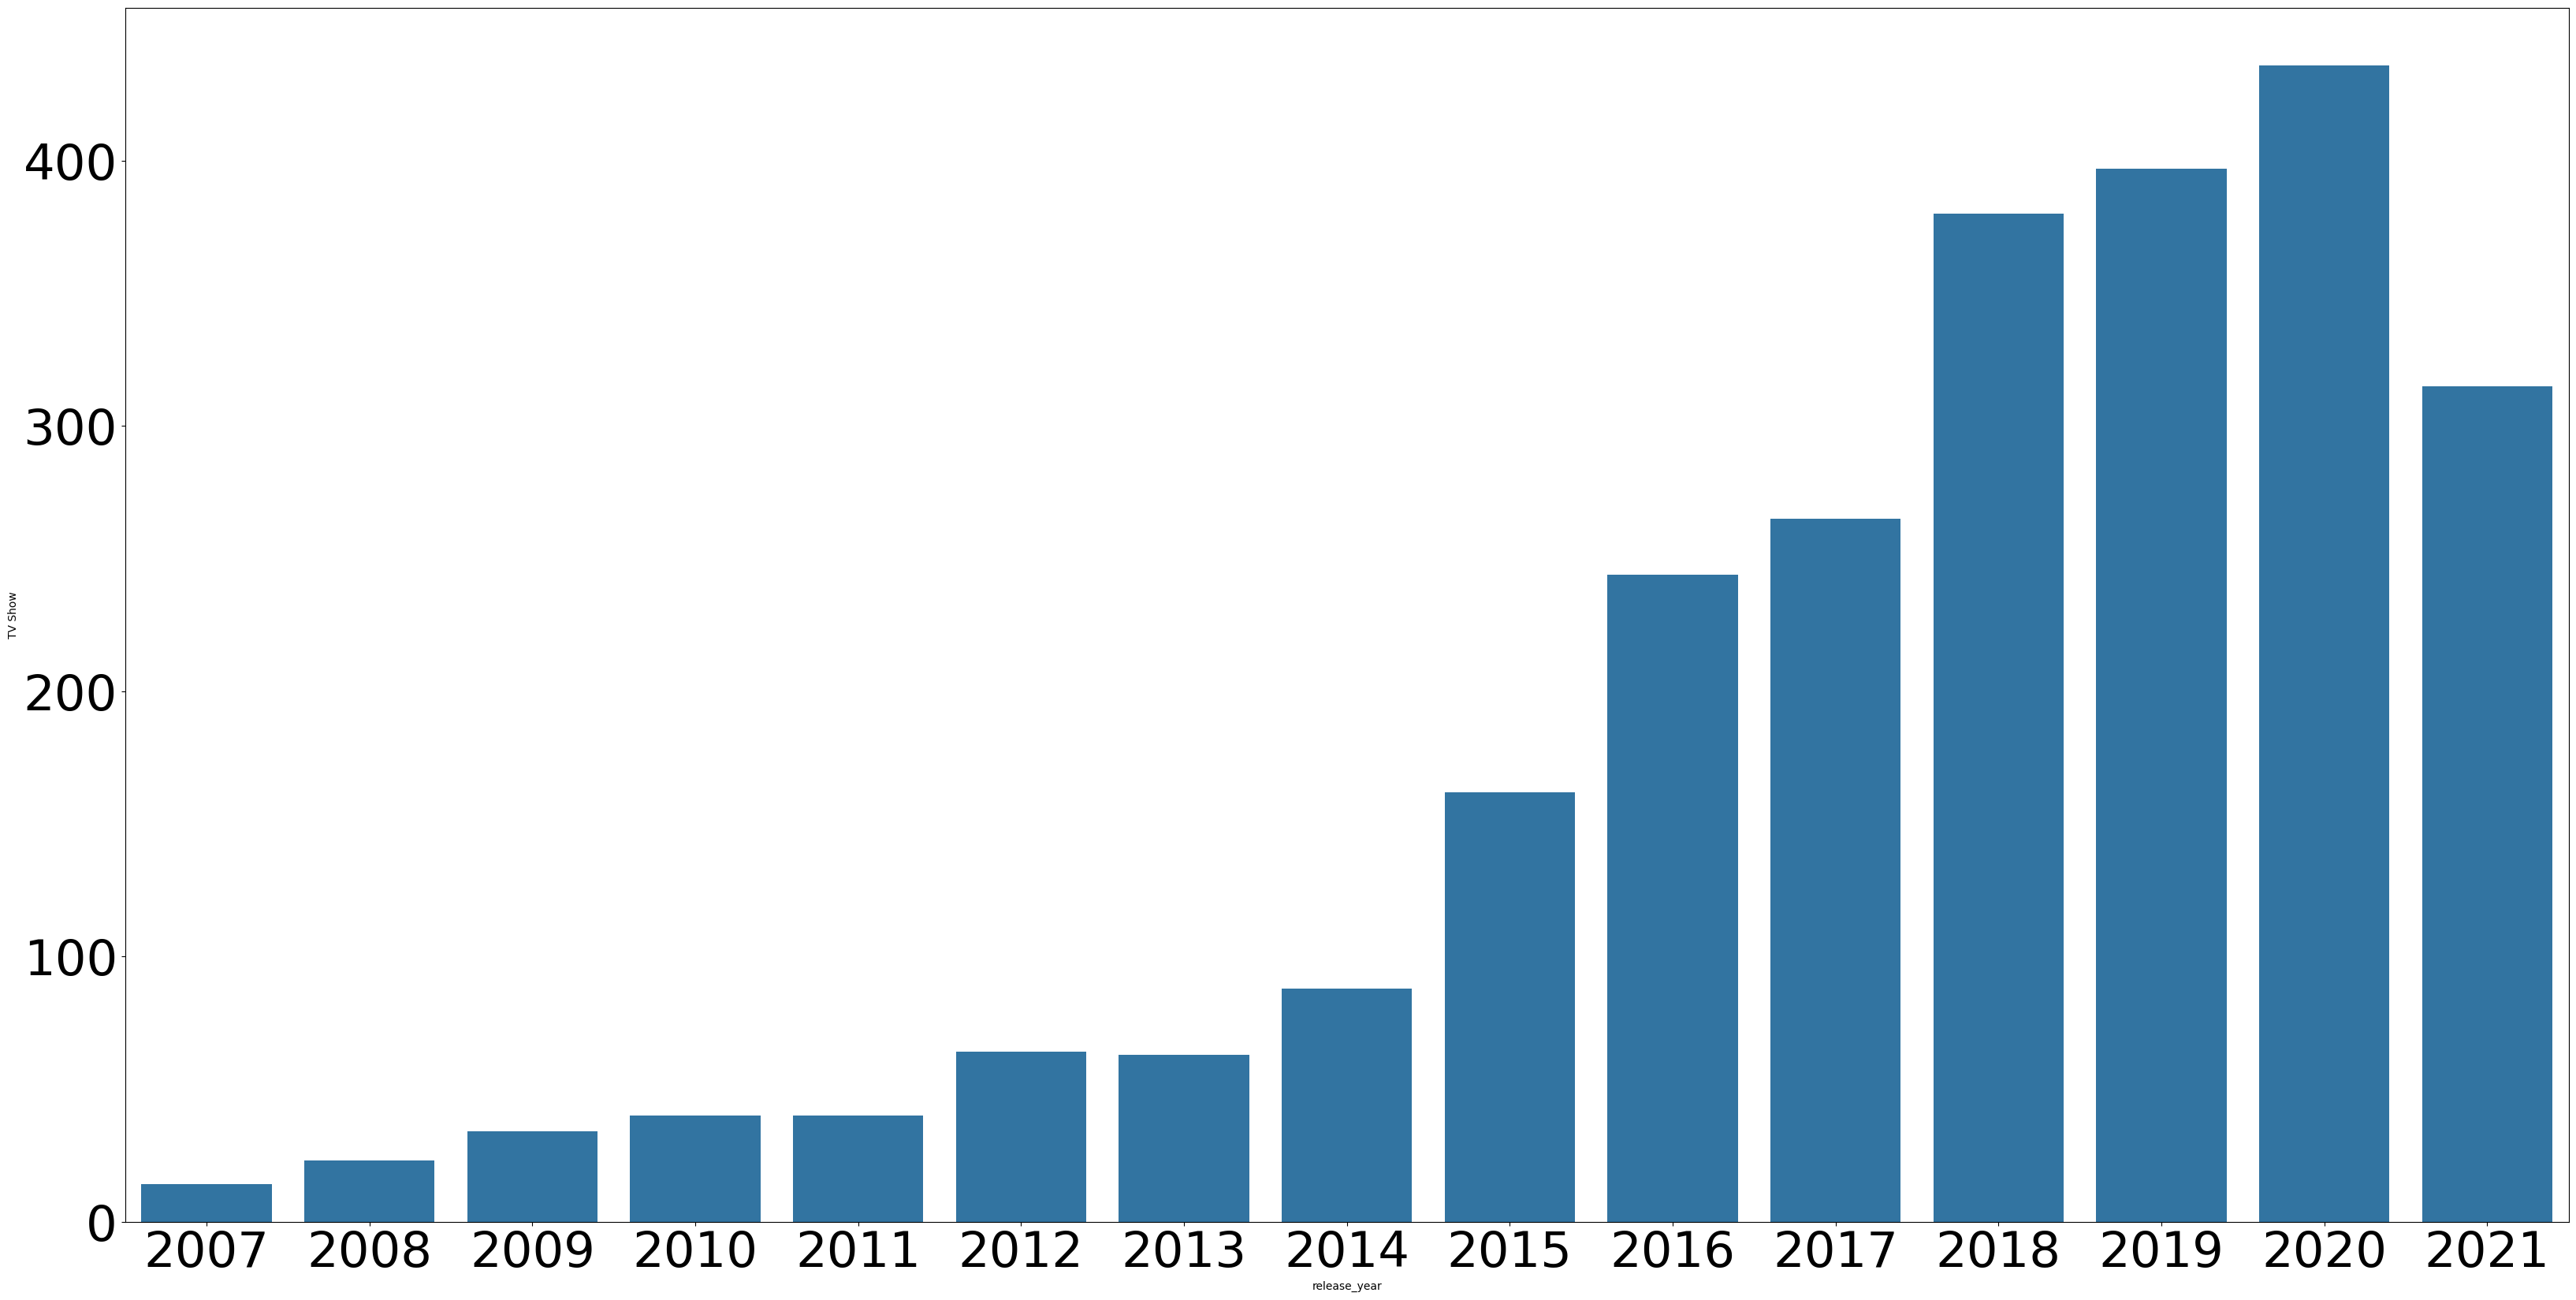

In [57]:
fig,ax=plt.subplots(figsize=(40,20))
top10 = rl_gp.sort_values(by='TV Show', ascending=False).head(15)
ax=sns.barplot(data=top10,y='TV Show',x='release_year')
plt.tick_params(labelsize=45)
plt.show()

In [58]:
top10

type,Movie,TV Show
release_year,,
2020,517.0,436.0
2019,633.0,397.0
2018,767.0,380.0
2021,277.0,315.0
2017,767.0,265.0
2016,658.0,244.0
2015,398.0,162.0
2014,264.0,88.0
2012,173.0,64.0


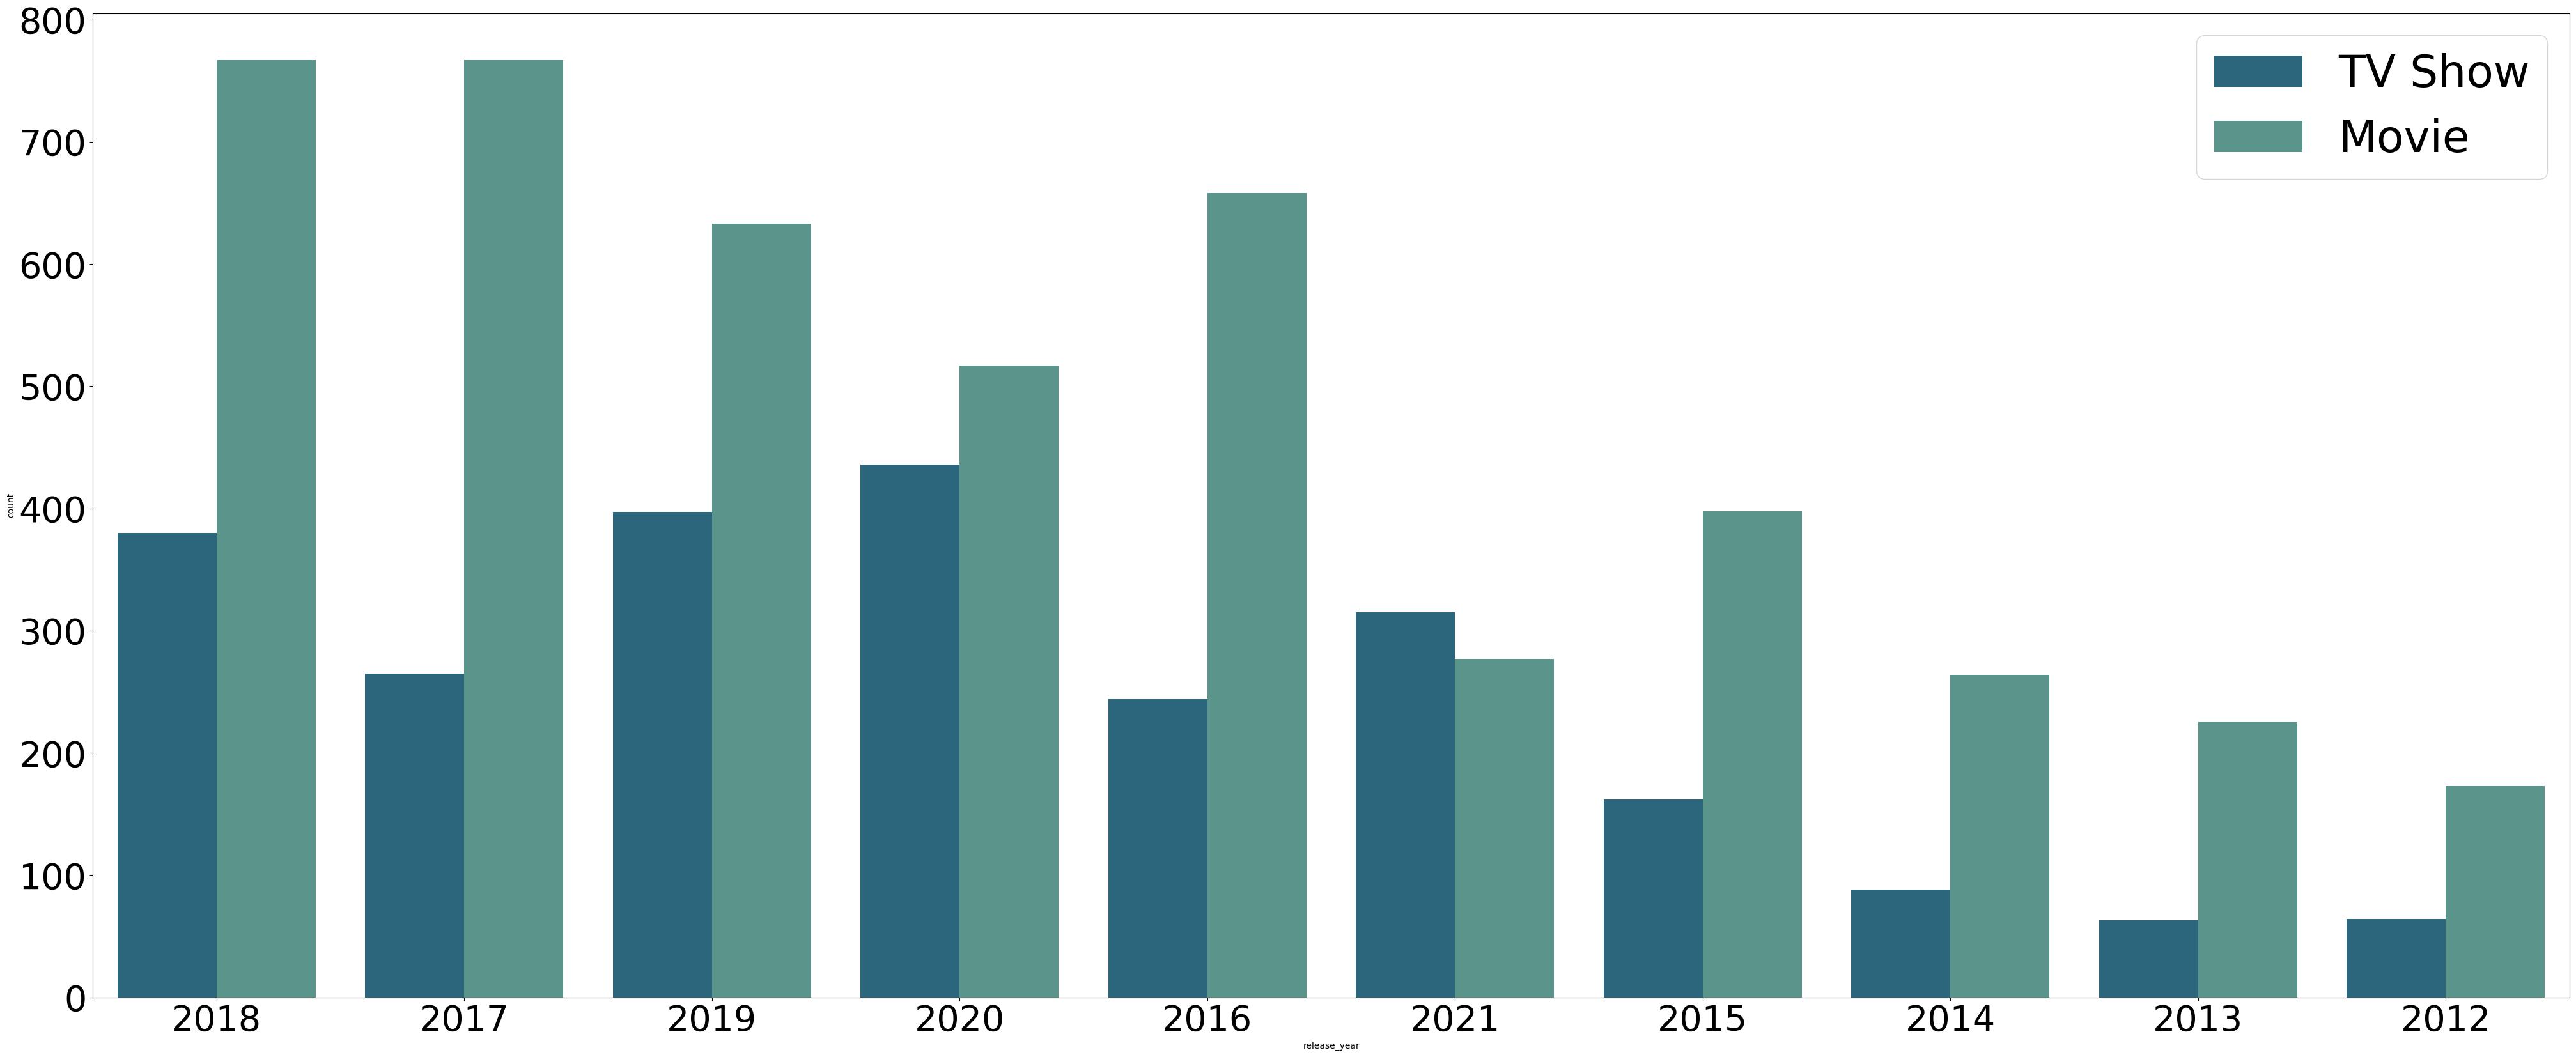

In [59]:
fig,ax=plt.subplots(figsize=(50, 20)) 
ax= sns.countplot(x='release_year', data=nf,palette='crest_r', hue='type', order =nf['release_year'].value_counts().index[0:10])

plt.tick_params(labelsize=40)
ax.legend(fontsize=50)
plt.show()


## which country has released most ?

In [60]:
nf['country'].value_counts(ascending=False)

country
United States     4041
India             1008
United Kingdom     626
Canada             271
Japan              259
                  ... 
Iran                 1
Slovenia             1
Guatemala            1
Jamaica              1
Somalia              1
Name: count, Length: 89, dtype: int64

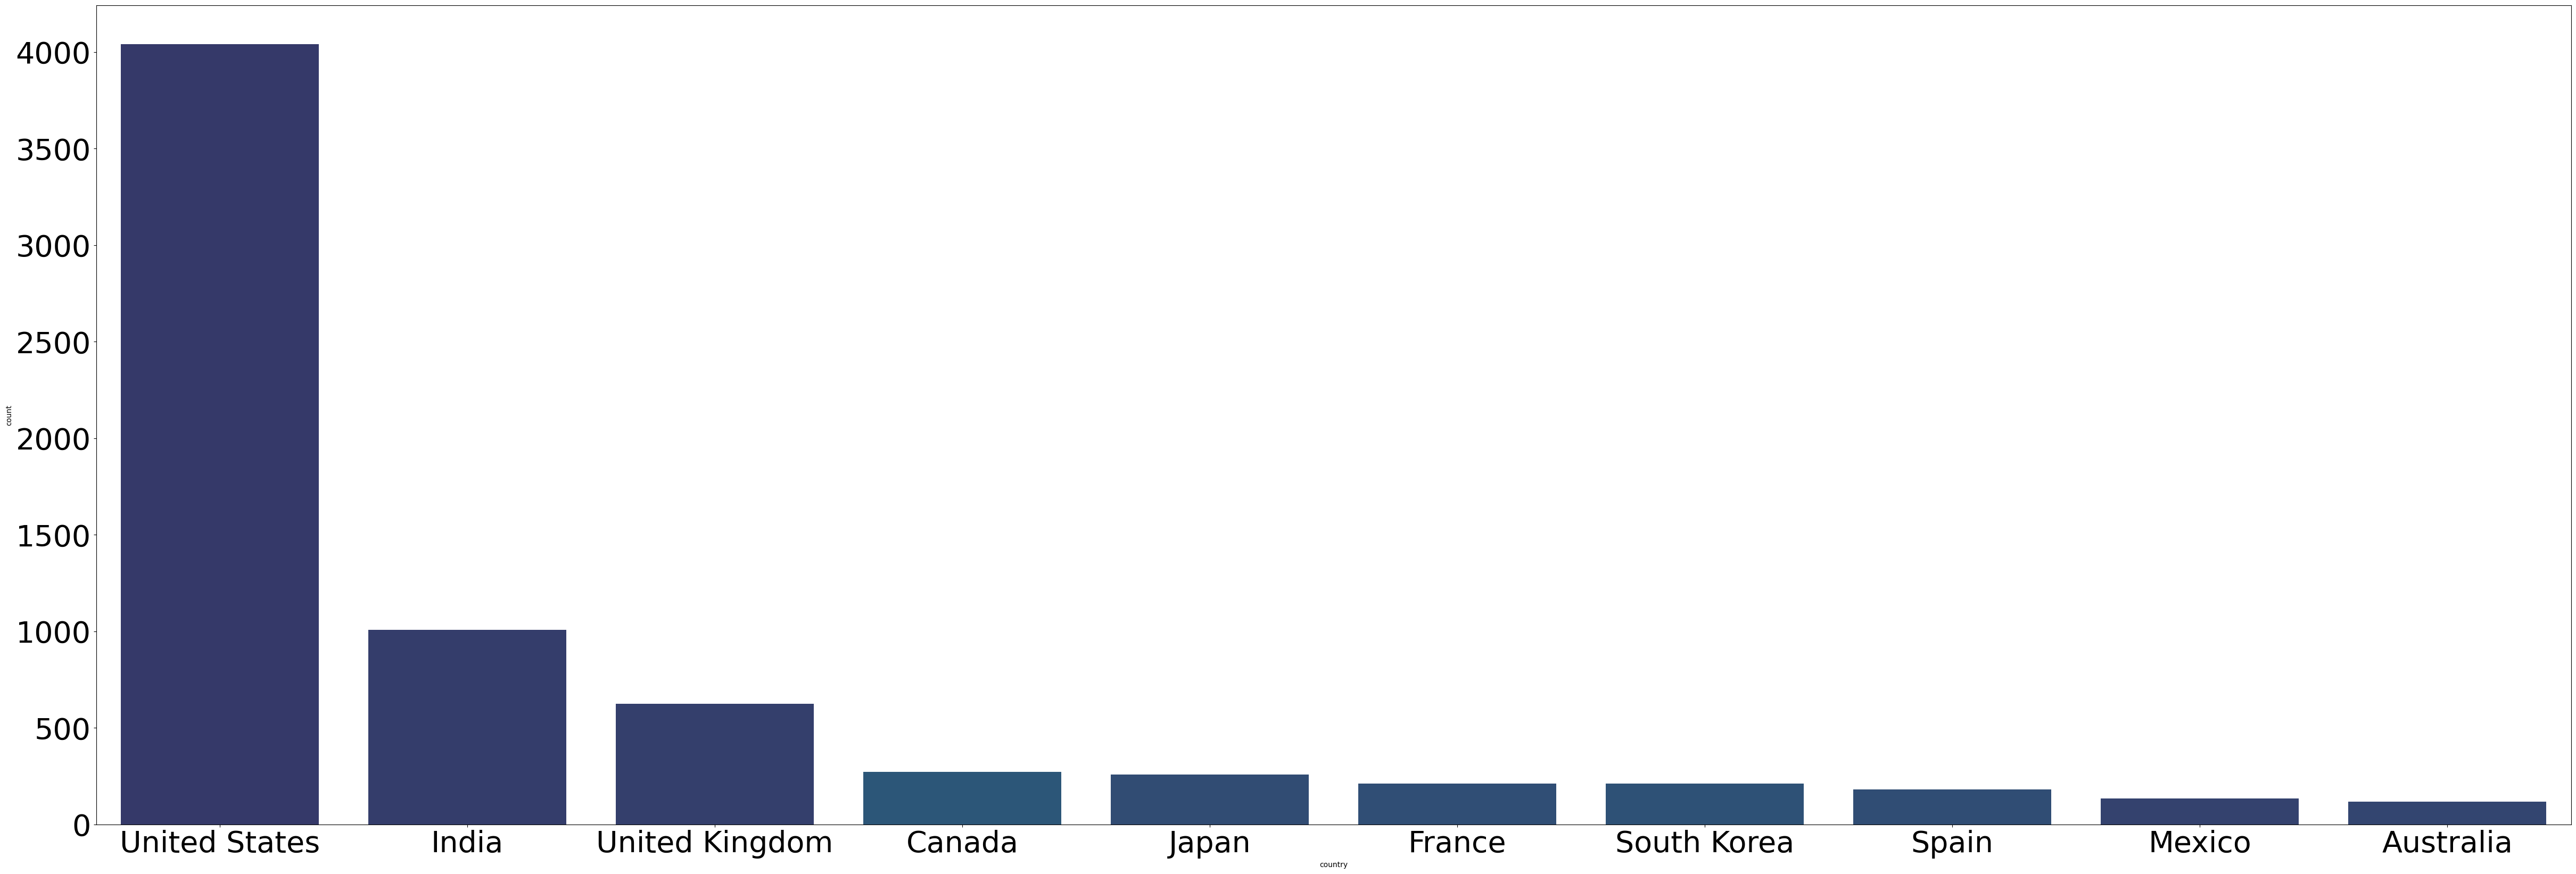

In [61]:
fig,ax=plt.subplots(figsize=(60,20))
ax=sns.countplot(data=nf,x='country',order=nf['country'].value_counts().index[0:10],palette='crest_r',hue='country')
plt.tick_params(labelsize=40)

plt.show()

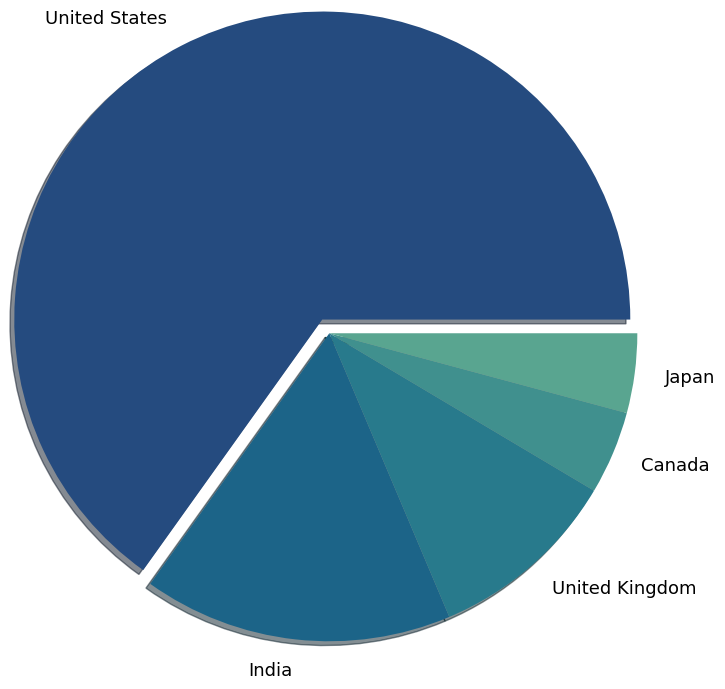

In [62]:
sizes=nf['country'].value_counts()
z=np.zeros(784)
z[0]=0.1

labels=[]
for i in sizes[:5].index:
    labels.append(i)

fig,ax=plt.subplots(figsize=(5,5))
ax.pie(sizes[:5],labels=labels,radius=2,explode=z[:5], textprops = {'fontsize':13},shadow = True, colors=sns.color_palette('crest_r'))

plt.show()

## what is the range of duration to movies/Tvshows?

In [63]:
nf['duration'].value_counts()

duration
1 Season     1796
2 Seasons     425
3 Seasons     199
90 min        152
97 min        146
             ... 
228 min         1
18 min          1
205 min         1
201 min         1
191 min         1
Name: count, Length: 220, dtype: int64

## what is the most popular rating in movies/Tv shows?

In [64]:
movie_gp=nf.groupby('type')['rating']

In [65]:
movie_gp.first()

type
Movie      PG-13
TV Show    TV-MA
Name: rating, dtype: object

In [66]:
nf

,type,title,director,cast,country,release_year,rating,duration,listed_in,month,uploaded_year
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2020,PG-13,90 min,Documentaries,September,2021
1,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries",September,2021
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",September,2021
3,TV Show,Jailbirds New Orleans,Unknown,Unknown,United States,2021,TV-MA,1 Season,"Docuseries, Reality TV",September,2021
4,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",September,2021
...,...,...,...,...,...,...,...,...,...,...,...
8802,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2007,R,158 min,"Cult Movies, Dramas, Thrillers",November,2019
8803,TV Show,Zombie Dumb,Unknown,Unknown,United States,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies",July,2019
8804,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2009,R,88 min,"Comedies, Horror Movies",November,2019
8805,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2006,PG,88 min,"Children & Family Movies, Comedies",January,2020


In [67]:
filt=(nf['type']=='TV Show')
nf[filt]['duration'].value_counts()

duration
1 Season      1793
2 Seasons      425
3 Seasons      199
4 Seasons       95
5 Seasons       65
6 Seasons       33
7 Seasons       23
8 Seasons       17
9 Seasons        9
10 Seasons       7
13 Seasons       3
12 Seasons       2
15 Seasons       2
11 Seasons       2
17 Seasons       1
Name: count, dtype: int64

In [68]:

nf[nf['duration']=='9 Seasons']

,type,title,director,cast,country,release_year,rating,duration,listed_in,month,uploaded_year
8,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021,TV-14,9 Seasons,"British TV Shows, Reality TV",September,2021
67,TV Show,Saved by the Bell,Unknown,"Mark-Paul Gosselaar, Tiffani Thiessen, Mario L...",United States,1994,TV-PG,9 Seasons,"Kids' TV, TV Comedies",September,2021
1480,TV Show,Still Game,Unknown,"Ford Kiernan, Paul Riley, Jane McCarry, Greg H...",United Kingdom,2018,TV-14,9 Seasons,"British TV Shows, Classic & Cult TV, Internati...",December,2020
1701,TV Show,American Horror Story,Unknown,"Evan Peters, Sarah Paulson, Jessica Lange, Den...",United States,2019,TV-MA,9 Seasons,"TV Horror, TV Mysteries, TV Thrillers",November,2020
1998,TV Show,Call the Midwife,Philippa Lowthorpe,"Vanessa Redgrave, Bryony Hannah, Helen George,...",United Kingdom,2020,TV-MA,9 Seasons,"British TV Shows, International TV Shows, TV D...",September,2020
3541,TV Show,Naruto,Hayato Date,"Junko Takeuchi, Chie Nakamura, Noriaki Sugiyam...",Japan,2006,TV-14,9 Seasons,"Anime Series, International TV Shows",September,2019
5803,TV Show,Forensic Files,Unknown,Peter Thomas,United States,2011,TV-MA,9 Seasons,"Crime TV Shows, Docuseries, Science & Nature TV",September,2016
6504,TV Show,Club Friday The Series 6,Unknown,"Puttichai Kasetsin, Kongtoranin Lalana, Preech...",United States,2015,TV-MA,9 Seasons,"International TV Shows, Romantic TV Shows, TV ...",March,2019
8442,TV Show,The Office (U.S.),Unknown,"Steve Carell, John Krasinski, Jenna Fischer, R...",United States,2012,TV-14,9 Seasons,TV Comedies,January,2016


In [69]:
nf

,type,title,director,cast,country,release_year,rating,duration,listed_in,month,uploaded_year
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2020,PG-13,90 min,Documentaries,September,2021
1,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries",September,2021
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",September,2021
3,TV Show,Jailbirds New Orleans,Unknown,Unknown,United States,2021,TV-MA,1 Season,"Docuseries, Reality TV",September,2021
4,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",September,2021
...,...,...,...,...,...,...,...,...,...,...,...
8802,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2007,R,158 min,"Cult Movies, Dramas, Thrillers",November,2019
8803,TV Show,Zombie Dumb,Unknown,Unknown,United States,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies",July,2019
8804,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2009,R,88 min,"Comedies, Horror Movies",November,2019
8805,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2006,PG,88 min,"Children & Family Movies, Comedies",January,2020
